# INT396 — Unsupervised Learning
## Practical-2: Partition-Based Clustering — k-Means, k-Medoids and Choosing k

### How this notebook is ordered

This is Unit II's practical, and it runs the four lab practicals of the unit
**in their own sequence**, one after another, on a single customer dataset:

| Part | Practical | What it covers |
|---|---|---|
| **1** | Practical 2 | k-Means, k-Medoids, fuzzy memberships, MiniBatch |
| **2** | Practical 3 | k-Means from scratch — the objective, Lloyd's two steps, initialisation |
| **3** | Practical 4 | Scaling — the step that decides your answer |
| **4** | Practical 5 | Choosing $k$ — elbow, silhouette, Davies–Bouldin |

Parts 1 and 2 work on the **raw** customer table, exactly as it arrives.
They will not produce a good segmentation, and that is deliberate: Part 3 is
where you find out why, and every result from Parts 1 and 2 gets re-run and
repaired there. Part 4 then chooses $k$ properly on the repaired table.

Run the cells in order, top to bottom.

## 0 · Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)
np.random.seed(7)

## 0.1 · Rebuild the customer feature table

In [2]:
n_per_group = 40

bargain_hunters = pd.DataFrame({
    "recency_days": np.random.normal(60, 15, n_per_group).clip(1),
    "frequency_per_year": np.random.normal(8, 2, n_per_group).clip(1),
    "monetary_value": np.random.normal(3500, 800, n_per_group).clip(200),
})

loyal_premium = pd.DataFrame({
    "recency_days": np.random.normal(8, 4, n_per_group).clip(1),
    "frequency_per_year": np.random.normal(30, 5, n_per_group).clip(1),
    "monetary_value": np.random.normal(65000, 9000, n_per_group).clip(200),
})

gift_shoppers = pd.DataFrame({
    "recency_days": np.random.normal(200, 40, n_per_group).clip(1),
    "frequency_per_year": np.random.normal(2, 0.6, n_per_group).clip(1),
    "monetary_value": np.random.normal(1500, 400, n_per_group).clip(200),
})

customers = pd.concat(
    [bargain_hunters, loyal_premium, gift_shoppers], ignore_index=True
)
customers["customer_id"] = ["C" + str(10000 + i) for i in range(len(customers))]
customers = customers[["customer_id", "recency_days", "frequency_per_year", "monetary_value"]]

# the feature matrix the algorithms will see - no ids, no labels
FEATURES = ["recency_days", "frequency_per_year", "monetary_value"]
X = customers[FEATURES].to_numpy(dtype=float)

# the group each simulated customer was drawn from - for marking our
# homework at the end, never for the algorithms themselves
truth = np.repeat([0, 1, 2], n_per_group)

customers.sample(5, random_state=1)

,customer_id,recency_days,frequency_per_year,monetary_value
95,C10095,239.031305,2.615823,924.365372
54,C10054,3.688060,25.298604,69279.135993
59,C10059,9.493323,33.326018,70331.467183
117,C10117,182.968224,1.633946,1529.532743
77,C10077,11.034901,33.182064,61875.162358


## 0.2 · Data cleaning and preprocessing

In [3]:
# Check data types and non-null values
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         120 non-null    str    
 1   recency_days        120 non-null    float64
 2   frequency_per_year  120 non-null    float64
 3   monetary_value      120 non-null    float64
dtypes: float64(3), str(1)
memory usage: 3.9 KB


In [4]:
# Check for missing values
print("Missing values in each column:")
print(customers.isnull().sum())

Missing values in each column:
customer_id           0
recency_days          0
frequency_per_year    0
monetary_value        0
dtype: int64


All three features are `float64` and `customer_id` is a string column, which is
what we want. The `Non-Null Count` is 120 for every column and
`isnull().sum()` is zero everywhere, so nothing needs imputing or dropping and we
can hand the table straight to an algorithm.

## 0.3 · Quick EDA on the unlabeled table

In [5]:
customers.describe()

,recency_days,frequency_per_year,monetary_value
count,120.000000,120.000000,120.000000
mean,88.724770,13.266860,23342.612873
std,85.301530,12.469975,29807.937842
min,1.000000,1.000000,580.300449
25%,9.977002,2.416119,1665.312974
50%,58.372993,7.768012,3635.897874
75%,179.486305,25.920688,60497.624599
max,258.414871,40.318978,80663.116659


Look at the `mean` and `std` rows across the three features, and notice how
different the numbers are in size. Recency lives in the tens, frequency in the
low tens, and monetary value in the tens of *thousands*. Hold on to that — it
becomes the single most important fact in this practical.

## 0.4 · Does structure look visible at all?

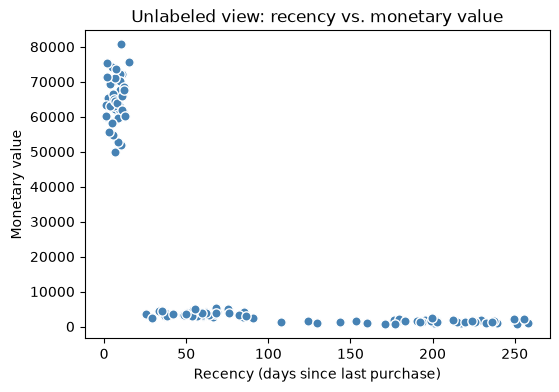

In [6]:
fig, ax = plt.subplots()
ax.scatter(customers["recency_days"], customers["monetary_value"],
           c="steelblue", edgecolor="white", s=45)
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Monetary value")
ax.set_title("Unlabeled view: recency vs. monetary value")
plt.show()

Three clumps again, just as in Practical 1. That is the honest starting point for
this practical: we believe there are about three groups because we can see three
groups, and our job now is to get an algorithm to find them without being told.

**Optional check (do not use this for real unsupervised work — it defeats
the purpose):** we can color by the group each simulated customer actually
came from, just to have something to mark our homework against at the end.

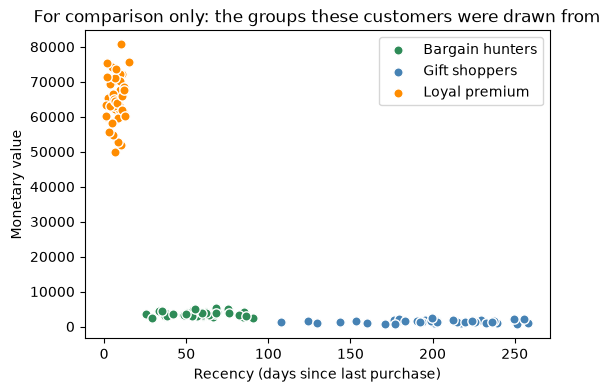

In [7]:
true_group = np.repeat(["Bargain hunters", "Loyal premium", "Gift shoppers"],
                       n_per_group)
customers_check = customers.copy()
customers_check["_true_group"] = true_group

fig, ax = plt.subplots()
colors = {"Bargain hunters": "seagreen", "Loyal premium": "darkorange",
          "Gift shoppers": "steelblue"}
for grp, sub in customers_check.groupby("_true_group"):
    ax.scatter(sub["recency_days"], sub["monetary_value"], label=grp,
               color=colors[grp], edgecolor="white", s=45)
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Monetary value")
ax.set_title("For comparison only: the groups these customers were drawn from")
ax.legend()
plt.show()

---
# Part 1 · Practical 2 — k-Means, k-Medoids and MiniBatch

We have a table of 120 customers and three features. Four algorithms in this
unit answer the same question — *group these customers around $k$ centres* —
and differ only in what a centre is allowed to be, and how much of the data is
consulted to place it.

Everything in this part runs on the table **exactly as it arrived**. No
transformation of any kind.

## 1.1 · A first run on the raw table

k-Means is the standard starting point for this kind of problem. You tell it
how many groups you want, it places that many centres, and every customer is
assigned to the nearest one.

We ask for three clusters, because three is what the plot suggests, and feed it
the table as it stands. Let us run it before we study it — the first result is
more instructive than the theory.

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

raw_km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)
customers["cluster_raw"] = raw_km.labels_

print("cluster sizes:", np.bincount(raw_km.labels_))
print()
print("Where k-Means put its three centres:")
print(pd.DataFrame(raw_km.cluster_centers_, columns=FEATURES).round(1).to_string())
print()
print("silhouette score       : %.3f" % silhouette_score(X, raw_km.labels_))
print("agreement with truth   : %.3f" % adjusted_rand_score(truth, raw_km.labels_))

cluster sizes: [24 80 16]

Where k-Means put its three centres:
   recency_days  frequency_per_year  monetary_value
0           6.7                29.8         60426.1
1         129.5                 5.0          2551.1
2           7.9                30.0         71674.7

silhouette score       : 0.839
agreement with truth   : 0.444


Read those two scores together, because they disagree.

The **silhouette score is high** — comfortably above 0.8, which any textbook
table would call "strong structure". But the **agreement with the true groups is
poor**: an adjusted Rand index of roughly 0.44 means the partition it found is
not the partition the customers actually came from.

Look at the cluster sizes too. One cluster holds 80 of the 120 customers and
the other two split the remaining 40 between them. Two of the three centres sit
almost on top of each other — both at about 30 purchases a year and a very
recent visit — and differ only in spend.

So we have a confident-looking clustering that is wrong, and the internal metric
is happily endorsing it. Before fixing anything, let us find out what it
actually did.

## 1.2 · Was anything except spend used?

Here is a direct test. We throw away two of the three features, cluster on
`monetary_value` **alone**, and compare that partition against the one we just
got from all three features. If they match, the other two features never
mattered.

In [9]:
spend_only = KMeans(n_clusters=3, n_init=10,
                    random_state=0).fit(X[:, [2]])   # monetary_value only

print("agreement between the two partitions:")
print("  all three features vs monetary_value alone : %.4f"
      % adjusted_rand_score(raw_km.labels_, spend_only.labels_))

agreement between the two partitions:
  all three features vs monetary_value alone : 1.0000


An adjusted Rand index of **1.0000** is not "similar" — it is *the same
partition, customer for customer*. Recency and frequency were in the model and
had no influence on it whatsoever.

Nothing went wrong mechanically. k-Means minimised exactly what it was asked to
minimise; it is just that `monetary_value` is measured in numbers thousands of
times larger than the others, so it supplied essentially all of the distance.

## 1.3 · Reading the centroids as business facts

A cluster label is a number, and nobody can act on a number. The step that turns
a clustering into a segmentation is reading the centroids back in their original
units and describing each one in a sentence.

The centroids are already in real units here, because we never transformed the
table — so we can read them straight off.

In [10]:
profile_raw = pd.DataFrame(raw_km.cluster_centers_, columns=FEATURES).round(1)
profile_raw["customers"] = np.bincount(raw_km.labels_)

def band(value, low, high, words):
    """Turn a centroid number into one of three plain-English words."""
    return words[0] if value < low else (words[1] if value < high else words[2])

description = []
for _, r in profile_raw.iterrows():
    recent = band(r["recency_days"], 30, 120,
                  ["bought very recently", "bought a while ago", "long lapsed"])
    often = band(r["frequency_per_year"], 5, 15,
                 ["buys rarely", "buys occasionally", "buys often"])
    spend = band(r["monetary_value"], 2500, 20000,
                 ["low spend", "mid spend", "high spend"])
    description.append(f"{recent}, {often}, {spend}")
profile_raw["reads as"] = description

print(profile_raw.to_string())

   recency_days  frequency_per_year  monetary_value  customers                                      reads as
0           6.7                29.8         60426.1         24  bought very recently, buys often, high spend
1         129.5                 5.0          2551.1         80     long lapsed, buys occasionally, mid spend
2           7.9                30.0         71674.7         16  bought very recently, buys often, high spend


This is where the failure stops being a number and becomes obvious.

Two of the three segments **read as exactly the same sentence** — *bought very
recently, buys often, high spend*. They are not two segments. They are one
segment that k-Means cut in half along the spend axis, because spend was the
only axis it could see. And the third "segment" is a bucket of 80 customers —
two thirds of the customer base — described in a single line.

Hand this table to a marketing team and they can build two campaigns for the
same people and one campaign for everybody else.

Notice that nothing warned us. The algorithm converged, returned three centres,
and scored 0.84 on the silhouette. The description step is what caught it, and
that step is not automatable — every word in the `reads as` column came from us
putting the centroid numbers next to what the business already knows.

## 1.4 · Hard labels and what they hide

`raw_km.labels_` gives every customer exactly one integer, with no indication of
how close the decision was. A customer sitting squarely inside a segment and one
sitting on the boundary between two receive labels that look identical.

**Soft**, or *fuzzy*, clustering keeps that information. Instead of one label it
gives each customer one weight per cluster, and the weights sum to 1. Each weight
is one over the distance squared, expressed as a share of the total:

$$u_{ij} \;=\; \dfrac{\dfrac{1}{d_{ij}^{\,2}}}
{\dfrac{1}{d_{i1}^{\,2}} + \dfrac{1}{d_{i2}^{\,2}} + \dfrac{1}{d_{i3}^{\,2}}}$$

Near centres give big reciprocals and therefore big weights.

In [11]:
def fuzzy_memberships(data, centres, m=2.0):
    """One weight per cluster for every point. Each row sums to 1."""
    d = np.linalg.norm(data[:, None, :] - centres[None, :, :], axis=2)
    d = np.fmax(d, 1e-12)                      # never divide by zero
    inv = 1.0 / d ** (2 / (m - 1))
    return inv / inv.sum(axis=1, keepdims=True)

U = fuzzy_memberships(X, raw_km.cluster_centers_)

print("every row sums to 1                    :", np.allclose(U.sum(axis=1), 1))
print("hard label is just the biggest weight  :",
      (U.argmax(axis=1) == raw_km.labels_).all())

every row sums to 1                    : True
hard label is just the biggest weight  : True


That second line is the whole relationship between the two ideas: **the hard
label is the soft memberships with everything but the winner thrown away.**

Now look at what gets thrown away.

In [12]:
confidence = U.max(axis=1)          # how strong is the winning weight?
order = np.argsort(confidence)

print("THE FIVE MOST AMBIGUOUS CUSTOMERS")
amb = pd.DataFrame(U[order[:5]].round(3), columns=["cluster_0", "cluster_1", "cluster_2"])
amb.insert(0, "customer_id", customers["customer_id"].to_numpy()[order[:5]])
amb["hard_label"] = raw_km.labels_[order[:5]]
print(amb.to_string(index=False))

print()
print("customers with a winning weight below 0.60 : %d" % (confidence < 0.60).sum())
print("customers with a winning weight above 0.90 : %d" % (confidence > 0.90).sum())

THE FIVE MOST AMBIGUOUS CUSTOMERS
customer_id  cluster_0  cluster_1  cluster_2  hard_label
     C10073      0.529      0.004      0.467           0
     C10060      0.401      0.004      0.595           2
     C10057      0.620      0.004      0.376           0
     C10065      0.645      0.004      0.352           0
     C10068      0.746      0.003      0.251           0

customers with a winning weight below 0.60 : 2
customers with a winning weight above 0.90 : 104


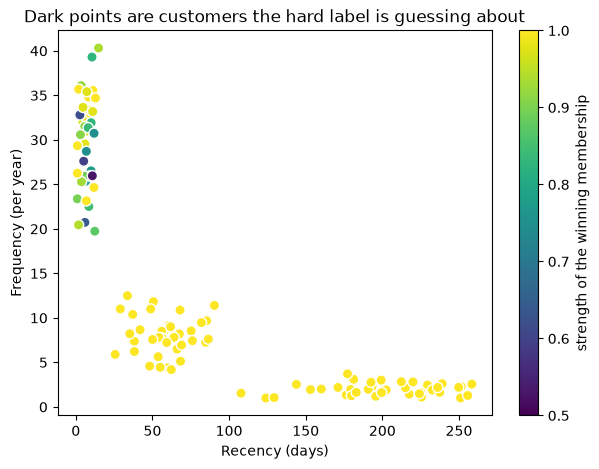

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(customers["recency_days"], customers["frequency_per_year"],
                c=confidence, cmap="viridis", s=55, edgecolor="white",
                vmin=0.5, vmax=1.0)
plt.colorbar(sc, ax=ax, label="strength of the winning membership")
ax.set_xlabel("Recency (days)")
ax.set_ylabel("Frequency (per year)")
ax.set_title("Dark points are customers the hard label is guessing about")
plt.show()

Read the ambiguous table's middle column first. Every one of those five
customers has a weight of about **0.004 for cluster 1** — the 80-customer bucket
— and splits the rest almost evenly between clusters 0 and 2.

That is the fuzzy version of what section 1.3 found. The customers are not
genuinely torn between three plausible segments; they are torn between the two
halves of a segment that should never have been cut in two, and they are certain
they are not in the third. The confidence numbers are describing the geometry of
a bad partition perfectly accurately.

So over a hundred of the 120 are placed with a winning weight above 0.90.
**High confidence in a wrong answer is still a wrong answer** — the membership
weights measure distance to the centres we happen to have, not whether those
centres are in the right place.

**What to do with this in practice:** ship the hard labels, but ship the
confidence alongside them. A customer assigned with a weight of 0.51 should not
receive the same campaign as one assigned with 0.99, and the hard label cannot
tell the two apart.

## 1.5 · k-Medoids

k-Means puts its centre at the **mean** of a cluster, which is a position in
space and need not be any real customer. k-Medoids requires the centre to be one
of your actual observations — a **medoid** — and adds up plain distances rather
than squared ones.

There is no formula for a medoid, so it has to be searched for: try each member
of the cluster as the candidate centre and keep whichever one is cheapest.

In [14]:
def kmedoids(data, k=3, iters=100, n_init=10, seed=0):
    """k-Medoids with Manhattan distance. Returns (medoid rows, labels, cost)."""
    rng = np.random.default_rng(seed)
    D = np.abs(data[:, None, :] - data[None, :, :]).sum(axis=2)
    best = None
    for _ in range(n_init):                       # restarts, as with n_init
        idx = rng.choice(len(data), k, replace=False)
        for _ in range(iters):
            lab = D[:, idx].argmin(axis=1)        # assign to nearest medoid
            new = idx.copy()
            for j in range(k):                    # re-choose each medoid
                mem = np.where(lab == j)[0]
                if len(mem):
                    new[j] = mem[D[np.ix_(mem, mem)].sum(axis=1).argmin()]
            if set(new) == set(idx):
                break
            idx = new
        lab = D[:, idx].argmin(axis=1)
        cost = D[np.arange(len(data)), idx[lab]].sum()
        if best is None or cost < best[2]:
            best = (idx.copy(), lab.copy(), cost)
    return best

med_idx, med_labels, med_cost = kmedoids(X, 3)

print("the three medoids are real customers:")
print(customers.loc[med_idx, ["customer_id"] + FEATURES].round(1).to_string(index=False))
print()
print("agreement with truth   : %.4f" % adjusted_rand_score(truth, med_labels))
print("agreement with k-Means : %.4f" % adjusted_rand_score(raw_km.labels_, med_labels))

the three medoids are real customers:
customer_id  recency_days  frequency_per_year  monetary_value
     C10077          11.0                33.2         61875.2
     C10069           1.9                35.7         71467.0
     C10023          90.4                11.4          2345.5

agreement with truth   : 0.4465
agreement with k-Means : 0.9891


The three medoids are **real customer records** — you can look up C10077 and
read their account. *"Our premium segment behaves like customer C10077"* is a
statement somebody can go and check. *"Our premium segment has an average spend
of 60,426"* — the centroid from section 1.1 — describes a customer who may not
exist.

Now read the two agreement figures, because they are the point of this section.

k-Medoids agrees with the true groups at about **0.45** — no better than k-Means
did. And it agrees with **k-Means at 0.99**: the two algorithms, with different
centre definitions and different distance measures, made almost exactly the same
mistake.

That is worth sitting with. Changing the algorithm did not help, because the
problem was never the algorithm. Both methods measure distance, and on this
table distance means spend. Swapping one distance-based method for another
cannot rescue you from a broken notion of distance.

## 1.6 · The outlier test

So if k-Medoids is no more accurate here, why does anyone use it? For a
different property: **robustness**.

We add a single corrupted row — one customer whose spend was typed with too many
zeros — and run both algorithms again. Nothing else changes.

In [15]:
X_bad = np.vstack([X, [30.0, 15.0, 5_000_000.0]])    # one data-entry error

km_bad = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_bad)
_, med_bad, _ = kmedoids(X_bad, 3)

print("                cluster sizes      agreement with truth")
print("k-Means      :   %-16s  %.4f"
      % (np.bincount(km_bad.labels_), adjusted_rand_score(truth, km_bad.labels_[:120])))
print("k-Medoids    :   %-16s  %.4f"
      % (np.bincount(med_bad), adjusted_rand_score(truth, med_bad[:120])))

                cluster sizes      agreement with truth
k-Means      :   [40  1 80]        0.5673
k-Medoids    :   [25 16 80]        0.4465


Look at the k-Means cluster sizes: `[40, 1, 80]`. One of the three clusters
contains a **single customer** — the bad row has been given a segment of its
own, so the 120 real customers are now described by two segments instead of
three.

Now look at k-Medoids. Its cluster sizes are unchanged from section 1.5, and its
agreement with the truth is **0.4465 — exactly the number it produced without
the corrupted row**. It did not notice.

The mechanism is the objective function. k-Means squares its distances, so a
point ten times further away counts a hundred times as much, and its centre is a
mean, which is free to be dragged anywhere. k-Medoids does not square, and its
centre is required to be a real customer — so there is simply nowhere for the
corrupted row to drag it to.

(k-Means' agreement actually *rose* to 0.57 here, which is an accident worth
naming: spending a whole cluster on the bad row left it only two clusters for
the real customers, which happened to stop it cutting the premium group in half.
A better score from a worse model — do not read too much into a single number.)

What robustness costs is time: k-Medoids has to search rather than compute, so
it works on thousands of rows where k-Means works on millions.

## 1.7 · MiniBatch k-Means for larger data

The third variant changes neither the objective nor the kind of centre — only how
much data is consulted at each step. Instead of using all $n$ customers to move
the centres, MiniBatch draws a small random sample each iteration.

Here is the arithmetic that motivates it, on a table of a million rows.

In [16]:
n_rows, batch, iterations = 1_000_000, 2_000, 50

print("full batch : %2d iterations x %9s rows = %13s point-evaluations"
      % (iterations, "{:,}".format(n_rows), "{:,}".format(iterations * n_rows)))
print("minibatch  : %2d iterations x %9s rows = %13s point-evaluations"
      % (iterations, "{:,}".format(batch), "{:,}".format(iterations * batch)))
print("                                              %d times fewer"
      % (n_rows // batch))

full batch : 50 iterations x 1,000,000 rows =    50,000,000 point-evaluations
minibatch  : 50 iterations x     2,000 rows =       100,000 point-evaluations
                                              500 times fewer


In [17]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.datasets import make_blobs
import time

# a dataset far too big to be interesting on 120 mall customers
X_big, _ = make_blobs(n_samples=300_000, centers=6, n_features=8,
                      cluster_std=1.4, random_state=1)
print("big dataset:", X_big.shape, " %.0f MB in memory" % (X_big.nbytes / 1e6))

def timed(model, data, repeats=2):
    """Fit twice and keep the second time, so start-up costs are not counted."""
    for _ in range(repeats):
        t0 = time.perf_counter()
        fitted = model.fit(data)
        dt = time.perf_counter() - t0
    return dt, fitted.inertia_, fitted.labels_

t_full, i_full, l_full = timed(
    KMeans(n_clusters=6, n_init=3, random_state=0), X_big)
t_mb, i_mb, l_mb = timed(
    MiniBatchKMeans(n_clusters=6, n_init=3, batch_size=1024, random_state=0), X_big)

print("  %-16s %6.2f s   inertia %.0f" % ("KMeans", t_full, i_full))
print("  %-16s %6.2f s   inertia %.0f" % ("MiniBatchKMeans", t_mb, i_mb))
print()
print("wall-clock ratio    : %.2fx" % (t_full / t_mb))
print("inertia given away  : %.3f%% worse" % (100 * (i_mb - i_full) / i_full))
print("do they agree?      : %.4f" % adjusted_rand_score(l_full, l_mb))

big dataset: (300000, 8)  19 MB in memory


  KMeans             0.36 s   inertia 4699015
  MiniBatchKMeans    0.48 s   inertia 4699242

wall-clock ratio    : 0.76x
inertia given away  : 0.005% worse
do they agree?      : 1.0000


Look at the last two lines first, because those are the ones that reproduce
anywhere: MiniBatch gave away a few thousandths of a percent of inertia, and its
partition agrees with the full-batch answer essentially point for point. It saw a
fraction of the data and reached the same segments.

The wall-clock ratio is the interesting one, and it may well have come out close
to — or even below — 1.0 on your machine. That is not a mistake, and it is worth
understanding rather than explaining away. The 500-fold saving in the cell above
is a count of *point-evaluations*, and it is real. But scikit-learn's full
`KMeans` is heavily optimised and runs across all your CPU cores, while
`MiniBatchKMeans` works through many small sequential updates. At a few hundred
thousand rows on a modern laptop, full k-Means is already fast enough that the
theoretical saving does not survive contact with the implementation.

So when is MiniBatch actually the right call? When the constraint is **memory
rather than arithmetic** — data that will not fit in RAM at all, or that arrives
as a stream and has to be clustered with `partial_fit` as it comes. That is the
situation the algorithm was designed for, and no amount of optimisation in
full-batch k-Means helps there, because full-batch k-Means needs the whole array
at once.

On our 120 customers, of course, you would see no benefit whatsoever — sampling
would only add noise to a problem that is already instantaneous.

## 1.8 · Where Part 1 leaves us

Four algorithms, one dataset, and not one usable segmentation between them:

* k-Means split one real group in two and merged the other two into a bucket of 80.
* k-Medoids made the same mistake, agreeing with k-Means at 0.99.
* The fuzzy memberships confidently endorsed the bad partition.
* The silhouette score gave the whole thing 0.84.

Every one of these ran correctly. The common factor is that all of them measure
distance, and we have not yet asked what distance means on this table.

Part 2 opens up k-Means and writes it from scratch, so that when we do ask that
question in Part 3, we know exactly which line of the algorithm the answer
lands on.

---
# Part 2 · Practical 3 — k-Means from scratch

Part 1 used `KMeans` as a black box. This part opens it: the number it
minimises, the two steps it repeats, and the one decision that turns out to
matter more than any of them.

Still on the raw table.

## 2.1 · What k-Means is actually minimising

Every run in Part 1 quietly optimised a single number, and it is worth seeing
that number written out. k-Means places $k$ centres so as to make the total
squared distance from each point to *its own* centre as small as possible. That
total is called the **inertia**, or the within-cluster sum of squares:

$$\text{WCSS} \;=\; \sum_{j\,=\,1}^{k}\ \ \sum_{x \,\in\, C_j}
\Big[\,d(x,\ \mu_j)\,\Big]^{2}$$

Go through the clusters one at a time; inside each, measure every customer's
distance to its own centre, square it, and keep a running total. Small total,
tight groups.

scikit-learn reports it as `.inertia_`. Let us confirm it really is just that sum.

In [18]:
manual = sum(((X[raw_km.labels_ == j] - raw_km.cluster_centers_[j]) ** 2).sum()
             for j in range(3))

print("inertia from the formula : %.4f" % manual)
print("raw_km.inertia_          : %.4f" % raw_km.inertia_)
print("identical                :", np.isclose(manual, raw_km.inertia_))

inertia from the formula : 770455987.5522
raw_km.inertia_          : 770455987.5522
identical                : True


`inertia_` is not a diagnostic that scikit-learn computes for your benefit — it
*is* the objective the algorithm was minimising, handed back to you.

Note the magnitude: about $7.7 \times 10^{8}$. That number is almost entirely
squared rupees, because squared distance on this table is almost entirely spend.
The objective function has the scale problem baked into it.

## 2.2 · The two steps, by hand

The algorithm itself is two steps repeated until nothing moves:

1. **Assign** — put every customer with the nearest centre.
2. **Update** — move every centre to the mean of the customers that just joined it.

Both steps can only lower the inertia or leave it unchanged, which is why the
algorithm always stops. Here are six full iterations written out, so you can see
the objective fall.

In [19]:
def assign(data, centres):
    """Step 1. Index of the nearest centre for every point."""
    d2 = ((data[:, None, :] - centres[None, :, :]) ** 2).sum(axis=2)
    return d2.argmin(axis=1)

def update(data, labels, centres):
    """Step 2. Move each centre to the mean of its members."""
    return np.array([data[labels == j].mean(axis=0) if (labels == j).any()
                     else centres[j] for j in range(len(centres))])

def wcss(data, labels, centres):
    return float(sum(((data[labels == j] - centres[j]) ** 2).sum()
                     for j in range(len(centres))))

# start from three customers picked at random
rng = np.random.default_rng(0)
centres = X[rng.choice(len(X), 3, replace=False)]

print("step                            inertia")
for it in range(6):
    labels = assign(X, centres)
    print("  iteration %d  assign   %16.1f" % (it, wcss(X, labels, centres)))
    centres = update(X, labels, centres)
    print("  iteration %d  update   %16.1f" % (it, wcss(X, labels, centres)))

print()
print("our inertia after 6 iterations : %.1f" % wcss(X, labels, centres))
print("scikit-learn's inertia         : %.1f" % raw_km.inertia_)

step                            inertia
  iteration 0  assign       6478058280.2
  iteration 0  update       1731119222.3
  iteration 1  assign       1460817176.8
  iteration 1  update       1299263651.5
  iteration 2  assign       1050089364.5
  iteration 2  update        902932960.3
  iteration 3  assign        834862486.3
  iteration 3  update        779683605.1
  iteration 4  assign        773749802.2
  iteration 4  update        770455987.6
  iteration 5  assign        770455987.6
  iteration 5  update        770455987.6

our inertia after 6 iterations : 770455987.6
scikit-learn's inertia         : 770455987.6


The number never rises. It falls steeply on the first update — from about
6.5 billion to 1.7 billion — then by less and less, and from iteration 5 it has
stopped moving at all. No customer changed hands, so no centre moved, so nothing
further can happen. The algorithm has **converged**.

The last two lines agree exactly. Thirty lines of NumPy reproduced
scikit-learn's answer to the decimal, which is the point of writing it out:
there is no hidden cleverness in k-Means. It is these two steps in a loop.

## 2.3 · Convergence is not the same as correctness

Both steps can only lower the inertia, so the algorithm is guaranteed to stop —
but it is only guaranteed to stop at a **local** minimum, one that cannot be
improved by moving any single customer or centre. Which local minimum you land
in is decided entirely by where the centres started.

Let us run the same code from eight different random starts and look at where
each one finishes.

In [20]:
rows = []
for seed in range(8):
    rng = np.random.default_rng(seed)
    centres = X[rng.choice(len(X), 3, replace=False)]
    for _ in range(50):
        labels = assign(X, centres)
        new_centres = update(X, labels, centres)
        if np.allclose(new_centres, centres):
            break
        centres = new_centres
    rows.append({"seed": seed,
                 "final_inertia": round(wcss(X, labels, centres), 1),
                 "agreement_with_truth": round(
                     adjusted_rand_score(truth, labels), 3)})

starts = pd.DataFrame(rows)
print(starts.to_string(index=False))
print()
print("best start reached      : %.1f" % starts["final_inertia"].min())
print("worst start reached     : %.1f" % starts["final_inertia"].max())
print("scikit-learn (n_init=10): %.1f" % raw_km.inertia_)

 seed  final_inertia  agreement_with_truth
    0    770455987.6                 0.444
    1    780033675.8                 0.438
    2   1882677188.4                 0.950
    3   1882677188.4                 0.950
    4   1882677188.4                 0.950
    5   1882677188.4                 0.950
    6    770455987.6                 0.444
    7   1882677188.4                 0.950

best start reached      : 770455987.6
worst start reached     : 1882677188.4
scikit-learn (n_init=10): 770455987.6


Read the two columns together, and then read them again, because this table says
something uncomfortable.

The eight starts landed in two clearly separated groups:

* three of them (seeds 0, 1, 6) at an inertia of **770–780 million**, with an
  agreement with the truth of about **0.44**;
* five of them (seeds 2, 3, 4, 5, 7) at **1,883 million** — nearly two and a
  half times worse on the objective — with an agreement of **0.95**.

**The runs that scored best on the objective returned the worst segmentation.**
The runs that k-Means considers failures are the ones that found the real
customer groups.

And scikit-learn, doing exactly what it should, reports the 770 million run.
`n_init=10` means it ran the whole algorithm ten times and kept the lowest
inertia — so the library's built-in safeguard against bad initialisation
reliably selects the answer we do not want.

Two separate lessons sit on top of each other here, and it is worth keeping them
apart:

1. **Initialisation matters.** Same data, same algorithm, same $k$, and the
   final inertia differs by a factor of 2.4 depending on the draw. This is why
   `n_init` exists, and why `init="k-means++"` spreads the starting centres out.
   The practical rule stands: **never trust a single run of k-Means.** If you
   ever see `n_init=1`, that is a result waiting to be wrong.

2. **Minimising the objective is not the same as being right.** No amount of
   `n_init` fixes the second problem, because more restarts only find *lower*
   inertia — and on this table lower inertia is worse. The objective itself is
   pointed at the wrong thing.

Part 3 is about why.

---
# Part 3 · Practical 4 — Scaling, the step that decides your answer

Everything in Parts 1 and 2 failed in the same direction, and it was not the
algorithms' fault. This part finds the cause, fixes it in one line, and then
re-runs every result from Part 1 on the repaired table.

## 3.1 · Where the distance actually goes

Take two customers, subtract them feature by feature, square each gap, and look
at what share of the total each feature contributed.

In [21]:
p = X[0]      # a bargain hunter
q = X[40]     # a loyal premium customer
gaps = (p - q) ** 2

share = pd.DataFrame({
    "feature": FEATURES,
    "customer_0": p.round(1),
    "customer_40": q.round(1),
    "squared_gap": gaps.round(1),
    "share_of_distance_%": (100 * gaps / gaps.sum()).round(4),
})
print("RAW UNITS")
print(share.to_string(index=False))

RAW UNITS
           feature  customer_0  customer_40  squared_gap  share_of_distance_%
      recency_days        85.4          6.4       6228.3               0.0003
frequency_per_year         9.7         25.4        245.6               0.0000
    monetary_value      4023.8      49849.4 2099991466.8              99.9997


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Z = scaler.fit_transform(X)

zgaps = (Z[0] - Z[40]) ** 2
share_z = pd.DataFrame({
    "feature": FEATURES,
    "squared_gap": zgaps.round(3),
    "share_of_distance_%": (100 * zgaps / zgaps.sum()).round(2),
})
print("AFTER STANDARDISATION")
print(share_z.to_string(index=False))

AFTER STANDARDISATION
           feature  squared_gap  share_of_distance_%
      recency_days        0.863                17.84
frequency_per_year        1.593                32.91
    monetary_value        2.383                49.25


On the raw numbers `monetary_value` takes about **99.9997%** of the squared
distance. Recency contributes three ten-thousandths of a percent and frequency
rounds to zero. The two features are present in the model and invisible to it.

After standardisation all three features are in play, and each share now reflects
how *unusual* that customer's value is for that feature rather than how large the
number happens to be.

Nothing about the two customers changed. Only the units did.

## 3.2 · Clustering the standardised table

Same algorithm, same $k$, same random seed. The only difference is that every
feature has been re-expressed in standard deviations first.

In [23]:
std_km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Z)
customers["cluster"] = std_km.labels_

print("               silhouette   agreement with truth")
print("raw          :   %.3f            %.3f"
      % (silhouette_score(X, raw_km.labels_),
         adjusted_rand_score(truth, raw_km.labels_)))
print("standardised :   %.3f            %.3f"
      % (silhouette_score(Z, std_km.labels_),
         adjusted_rand_score(truth, std_km.labels_)))
print()
print("does it still just follow spend?  %.4f"
      % adjusted_rand_score(std_km.labels_,
                            KMeans(n_clusters=3, n_init=10,
                                   random_state=0).fit_predict(Z[:, [2]])))

               silhouette   agreement with truth
raw          :   0.839            0.444
standardised :   0.763            0.950

does it still just follow spend?  0.4446


This is the most important table in the practical, and it is worth reading
slowly.

Standardising moved the agreement with the real groups from about **0.44 to
about 0.95** — from a wrong answer to very nearly a right one. And the
"does it still just follow spend?" figure has dropped from a perfect 1.0000 to
around 0.44, which is exactly what we wanted: all three features are now
contributing.

Now look at the silhouette column. It went **down**, from about 0.84 to about
0.76. The clustering got substantially better and the internal metric got worse.

That is not a bug in the silhouette score, and it is the single most useful
warning in this notebook: **an internal metric measures the geometry of the
partition, not whether the partition is right.** The raw clustering really did
produce tight, well-separated blobs — they were tight, well-separated blobs *of
the wrong thing*.

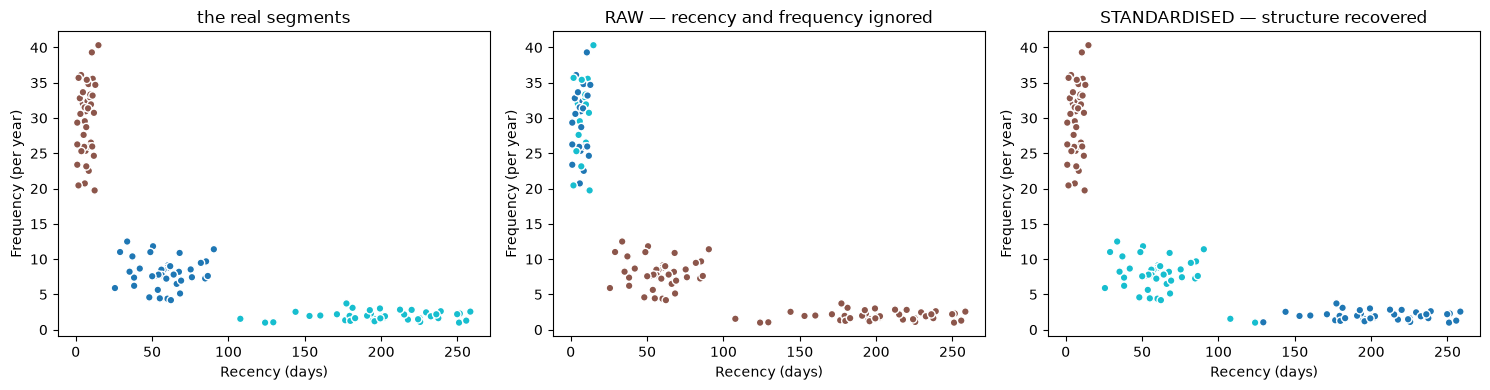

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(customers["recency_days"], customers["frequency_per_year"],
              c=truth, cmap="tab10", s=30, edgecolor="white")
ax[0].set_title("the real segments")
ax[1].scatter(customers["recency_days"], customers["frequency_per_year"],
              c=raw_km.labels_, cmap="tab10", s=30, edgecolor="white")
ax[1].set_title("RAW — recency and frequency ignored")
ax[2].scatter(customers["recency_days"], customers["frequency_per_year"],
              c=std_km.labels_, cmap="tab10", s=30, edgecolor="white")
ax[2].set_title("STANDARDISED — structure recovered")
for a in ax:
    a.set_xlabel("Recency (days)")
    a.set_ylabel("Frequency (per year)")
plt.tight_layout()
plt.show()

The middle panel is the one to remember. The colours cut across a plot of recency
against frequency in bands that have nothing to do with either axis — because the
grouping was decided by a third feature that is not on the plot at all.

Both runs converged. Both produced a silhouette score. Neither issued a warning.

## 3.3 · The segments, re-read

This is the same description code as section 1.3, unchanged. The only difference
is which clustering it is reading. The centroids live in standardised units now,
so we invert the scaler first to get back to rupees and days.

In [25]:
centres_real = scaler.inverse_transform(std_km.cluster_centers_)
profile = pd.DataFrame(centres_real, columns=FEATURES).round(1)
profile["customers"] = np.bincount(std_km.labels_)

description = []
for _, r in profile.iterrows():
    recent = band(r["recency_days"], 30, 120,
                  ["bought very recently", "bought a while ago", "long lapsed"])
    often = band(r["frequency_per_year"], 5, 15,
                 ["buys rarely", "buys occasionally", "buys often"])
    spend = band(r["monetary_value"], 2500, 20000,
                 ["low spend", "mid spend", "high spend"])
    description.append(f"{recent}, {often}, {spend}")
profile["reads as"] = description

print(profile.to_string())

   recency_days  frequency_per_year  monetary_value  customers                                          reads as
0         204.9                 2.0          1425.0         38               long lapsed, buys rarely, low spend
1           7.2                29.9         64925.5         40      bought very recently, buys often, high spend
2          61.2                 7.6          3570.1         42  bought a while ago, buys occasionally, mid spend


Compare this against the table in section 1.3, line for line.

| | raw (§1.3) | standardised (here) |
|---|---|---|
| segment sizes | 24 / 80 / 16 | 38 / 40 / 42 |
| distinct descriptions | **2** | **3** |
| a 2-of-3 bucket? | yes, 80 customers | no |

Three sentences a marketing team can act on, each one a different group of
roughly equal size:

* **long lapsed, buys rarely, low spend** — the gift shoppers, dormant and worth a win-back campaign;
* **bought very recently, buys often, high spend** — the loyal premium segment, worth protecting;
* **bought a while ago, buys occasionally, mid spend** — the bargain hunters in the middle.

Same customers, same algorithm, same $k$, same seed, same description code. One
line of preprocessing separates a table nobody can use from a table a marketing
team can run a season on.

## 3.4 · The other algorithms, re-run

Part 1 ran k-Medoids and the fuzzy memberships on the raw table and got a poor
answer from both. Neither algorithm has changed. Only the table has.

In [26]:
med_idx_z, med_labels_z, _ = kmedoids(Z, 3)
U_z = fuzzy_memberships(Z, std_km.cluster_centers_)
conf_z = U_z.max(axis=1)

print("k-MEDOIDS")
print("  raw table          : agreement with truth %.4f"
      % adjusted_rand_score(truth, med_labels))
print("  standardised table : agreement with truth %.4f"
      % adjusted_rand_score(truth, med_labels_z))
print()
print("  the three medoids are real customers:")
print(customers.loc[med_idx_z, ["customer_id"] + FEATURES].round(1).to_string(index=False))
print()
print("FUZZY MEMBERSHIPS  (customers with a winning weight above 0.90)")
print("  raw table          : %d of 120" % (confidence > 0.90).sum())
print("  standardised table : %d of 120" % (conf_z > 0.90).sum())

k-MEDOIDS
  raw table          : agreement with truth 0.4465
  standardised table : agreement with truth 1.0000

  the three medoids are real customers:
customer_id  recency_days  frequency_per_year  monetary_value
     C10070           8.1                31.4         63857.8
     C10022          54.2                 7.8          3813.2
     C10105         202.5                 1.9          1264.1

FUZZY MEMBERSHIPS  (customers with a winning weight above 0.90)
  raw table          : 104 of 120
  standardised table : 107 of 120


k-Medoids goes from **0.4465 to 1.0000** — a perfect recovery of the three real
groups, better than k-Means managed on the same table. The algorithm is
character-for-character the code from section 1.5. It was always capable of
this; it was never given a table on which distance meant anything.

That is the honest summary of section 1.5's result. k-Medoids was not the wrong
choice of algorithm. It was the right algorithm applied before the right
preprocessing, and no amount of algorithm selection substitutes for that.

The fuzzy weights barely move, and that is the point made in section 1.4 coming
back: confidence was high on the raw table too. **Membership strength tells you
how cleanly the data splits around the centres you have, and says nothing about
whether those centres are the right ones.**

## 3.5 · Which scaler?

`StandardScaler` is the sensible default, but it is not the only option, and it
is worth knowing what the alternatives do when the data is dirty. We reuse the
single corrupted row from section 1.6 — the customer whose spend was typed with
too many zeros — and rerun with each scaler.

In [27]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

rows = []
for name, sc in [("none", None),
                 ("StandardScaler", StandardScaler()),
                 ("MinMaxScaler", MinMaxScaler()),
                 ("RobustScaler", RobustScaler())]:
    Xs = X_bad if sc is None else sc.fit_transform(X_bad)
    lab = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(Xs)
    rows.append({"scaler": name,
                 "cluster_sizes": str(np.bincount(lab)),
                 "agreement_with_truth": round(
                     adjusted_rand_score(truth, lab[:120]), 3)})

print(pd.DataFrame(rows).to_string(index=False))

        scaler cluster_sizes  agreement_with_truth
          none    [40  1 80]                 0.567
StandardScaler    [40 80  1]                 0.567
  MinMaxScaler    [40 38 43]                 0.950
  RobustScaler    [40  1 80]                 0.567


Read the `cluster_sizes` column first. With no scaling at all, and under both
`StandardScaler` and `RobustScaler`, one of the three clusters contains a
**single customer** — the bad row has been given a segment of its own, so the 120
real customers are now described by two segments instead of three.

`MinMaxScaler` appears to do best here, and it is worth being honest about why,
because the reason is not flattering. Min–max squeezes every value into
$[0,1]$ using the largest observation as the ceiling. That one absurd spend
became the ceiling, which crushed every real customer's spend down to almost
zero — so spend effectively *dropped out of the model*, and recency and frequency
alone happened to be enough. It got the right answer by deleting a feature.

The general rule: **a scaler is not an outlier fix.** None of these four rows
repaired the data. Find the bad row and deal with it.

## 3.6 · Where Part 3 leaves us

| result | Part 1 (raw) | Part 3 (standardised) |
|---|---|---|
| k-Means agreement with truth | 0.44 | **0.95** |
| k-Medoids agreement with truth | 0.45 | **1.00** |
| distinct segment descriptions | 2 of 3 | **3 of 3** |
| silhouette score | 0.84 | 0.76 |

Everything got better except the metric. Keep that last row in mind for Part 4,
where we use metrics of exactly that kind to choose $k$.

---
# Part 4 · Practical 5 — Choosing the number of clusters

Everything so far assumed $k=3$, which we chose by looking at a scatter plot.
That works for two features and fails completely for twenty, so we need methods
that do not rely on being able to see the data.

There is no accuracy to compute here — there are no labels. What we have are
**internal** measures, which examine the geometry of the result and nothing else.
All of this part runs on the standardised table `Z`.

## 4.1 · The Elbow Method

Inertia measures compactness alone. It has a structural weakness: adding a
cluster can never make it worse, so it falls forever as $k$ rises and reaches
exactly zero when every customer is their own cluster. It therefore cannot be
minimised to choose $k$ — it can only be inspected for a bend.

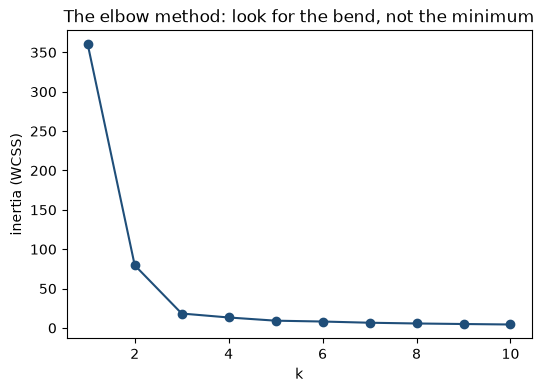

In [28]:
ks = list(range(1, 11))
inertias = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z).inertia_
            for k in ks]

fig, ax = plt.subplots()
ax.plot(ks, inertias, marker="o", color="#1F4E79")
ax.set_xlabel("k")
ax.set_ylabel("inertia (WCSS)")
ax.set_title("The elbow method: look for the bend, not the minimum")
plt.show()

Staring at a curve and announcing where it bends is not a method, it is an
opinion. Tabulate the **drop at each step** instead — how much inertia the $k$-th
cluster actually bought you. The elbow is where the drops collapse.

In [29]:
drops = [np.nan] + [inertias[i - 1] - inertias[i] for i in range(1, len(ks))]

elbow = pd.DataFrame({"k": ks,
                      "inertia": np.round(inertias, 1),
                      "drop_from_previous": np.round(drops, 1)})
print(elbow.to_string(index=False))

 k  inertia  drop_from_previous
 1    360.0                 NaN
 2     79.6               280.4
 3     18.3                61.3
 4     13.3                 5.0
 5      9.3                 4.1
 6      8.2                 1.1
 7      6.6                 1.5
 8      5.7                 0.9
 9      5.0                 0.7
10      4.4                 0.6


The drops collapse after $k=3$ — from a drop of about 61 down to about 5. The
third cluster bought a large improvement; the fourth bought almost nothing. The
elbow is at **k = 3**.

Notice also that the inertia column keeps falling all the way to $k=10$ and shows
no sign of stopping. If you tried to pick the $k$ with the smallest inertia you
would always be told to give every customer their own cluster.

## 4.2 · The Silhouette Coefficient

The silhouette is scored one customer at a time, and it asks the question the
customer themself would ask: *am I in the right cluster?* It compares $a(i)$, the
mean distance to their own clustermates, against $b(i)$, the mean distance to the
members of the nearest other cluster:

$$s(i) \;=\; \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}$$

It runs from $-1$ to $+1$. A value near $+1$ means comfortably placed, near $0$
means sitting on a boundary, and **below $0$ means the customer is closer to
another cluster than to their own** — that is, in the wrong one. No other measure
in this practical can say that about an individual.

Let us compute it for one customer straight from the definition, then check it
against scikit-learn.

In [30]:
from sklearn.metrics import silhouette_samples

i = 0
own = std_km.labels_[i]
a_i = np.linalg.norm(Z[std_km.labels_ == own] - Z[i], axis=1).sum() / \
      (np.sum(std_km.labels_ == own) - 1)          # exclude the point itself
b_i = min(np.linalg.norm(Z[std_km.labels_ == c] - Z[i], axis=1).mean()
          for c in np.unique(std_km.labels_) if c != own)

print("customer %s" % customers.loc[i, "customer_id"])
print("  a(i)  mean distance to own clustermates    : %.4f" % a_i)
print("  b(i)  mean distance to nearest other group : %.4f" % b_i)
print("  s(i) = (b - a) / max(a, b)                 : %.4f"
      % ((b_i - a_i) / max(a_i, b_i)))
print("  scikit-learn's silhouette_samples          : %.4f"
      % silhouette_samples(Z, std_km.labels_)[i])

customer C10000
  a(i)  mean distance to own clustermates    : 0.4190
  b(i)  mean distance to nearest other group : 1.5496
  s(i) = (b - a) / max(a, b)                 : 0.7296
  scikit-learn's silhouette_samples          : 0.7296


An average silhouette is one number standing in for 120 of them, and two
clusterings with the same average can be very different — one uniformly mediocre,
the other excellent everywhere except a single cluster that should not exist. The
**silhouette plot** shows every customer's $s(i)$, grouped by cluster, so you can
see which is which.

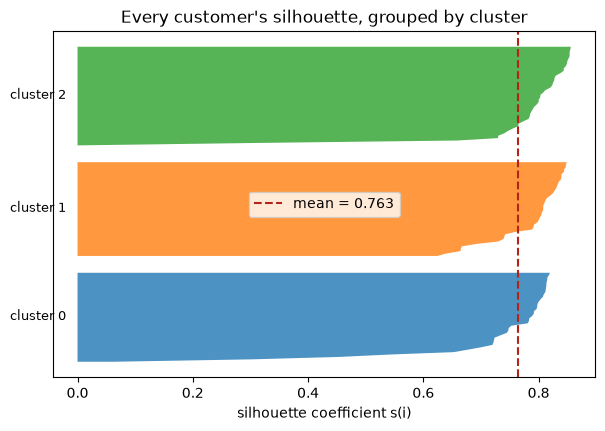

In [31]:
vals = silhouette_samples(Z, std_km.labels_)
mean_s = silhouette_score(Z, std_km.labels_)

fig, ax = plt.subplots(figsize=(7, 4.5))
y_lower = 0
for j in range(3):
    v = np.sort(vals[std_km.labels_ == j])
    ax.fill_betweenx(np.arange(y_lower, y_lower + len(v)), 0, v, alpha=0.8)
    ax.text(-0.02, y_lower + len(v) / 2, "cluster %d" % j,
            ha="right", va="center", fontsize=9)
    y_lower += len(v) + 6
ax.axvline(mean_s, color="#B42318", linestyle="--",
           label="mean = %.3f" % mean_s)
ax.set_xlabel("silhouette coefficient s(i)")
ax.set_yticks([])
ax.set_title("Every customer's silhouette, grouped by cluster")
ax.legend()
plt.show()

All three blocks sit well to the right of zero and are of similar width, which is
what a healthy clustering looks like. A cluster whose block was short, ragged, or
poking into negative territory would be one to investigate — those are customers
the algorithm had to put somewhere.

## 4.3 · The Davies–Bouldin Index

Davies–Bouldin measures compactness **and** separation together, but per *pair of
clusters* rather than per customer. For each pair it compares their combined
spread against the distance between their centres:

$$R_{ij} \;=\; \frac{S_i + S_j}{M_{ij}}
\qquad\text{then}\qquad
\text{DB} \;=\; \frac{R_1^{\max} + R_2^{\max} + \cdots + R_k^{\max}}{k}$$

where $S_j$ is the mean distance from a cluster's members to its own centroid and
$M_{ij}$ is the distance between two centroids. Each cluster is scored by its
**worst** partner, and those scores are averaged. Lower is better.

In [32]:
from sklearn.metrics import davies_bouldin_score

def davies_bouldin(data, labels):
    """Davies-Bouldin, straight from the definition above."""
    ids = np.unique(labels)
    centroids = np.array([data[labels == j].mean(axis=0) for j in ids])
    S = np.array([np.linalg.norm(data[labels == j] - centroids[i], axis=1).mean()
                  for i, j in enumerate(ids)])
    worst = []
    for i in range(len(ids)):
        ratios = [(S[i] + S[j]) / np.linalg.norm(centroids[i] - centroids[j])
                  for j in range(len(ids)) if j != i]
        worst.append(max(ratios))
    return float(np.mean(worst))

print("our implementation : %.4f" % davies_bouldin(Z, std_km.labels_))
print("scikit-learn       : %.4f" % davies_bouldin_score(Z, std_km.labels_))

our implementation : 0.2961
scikit-learn       : 0.2961


## 4.4 · All Three Together

Unlike inertia, the silhouette and Davies–Bouldin do not improve forever as $k$
grows — cutting a real segment in two damages the separation term. So they have a
genuine optimum and can actually be optimised, rather than merely inspected.

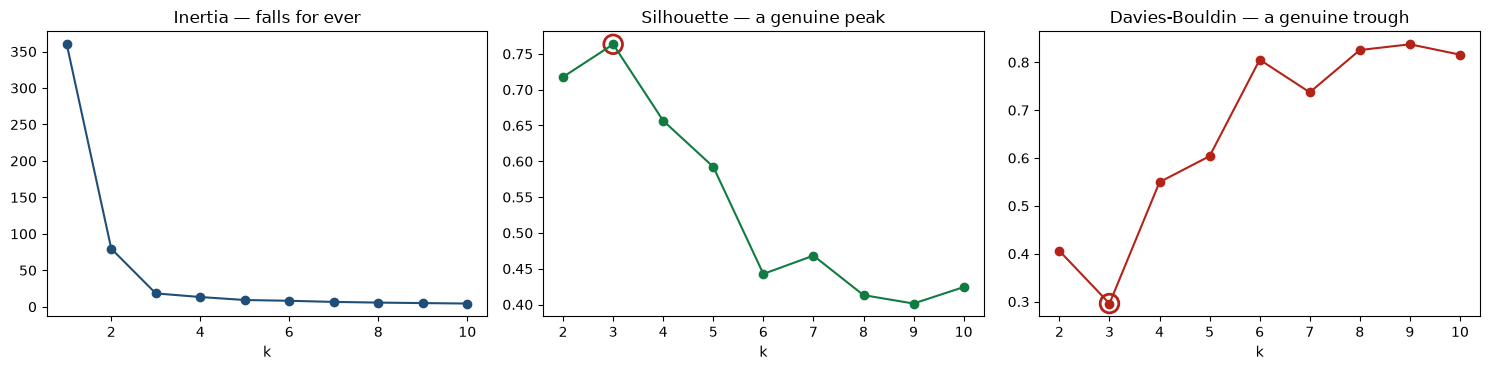

 k  silhouette  davies_bouldin
 2      0.7178          0.4060
 3      0.7634          0.2961
 4      0.6566          0.5498
 5      0.5922          0.6039
 6      0.4427          0.8054
 7      0.4683          0.7373
 8      0.4131          0.8255
 9      0.4014          0.8376
10      0.4243          0.8159

silhouette is highest at k = 3
davies-bouldin is lowest at k = 3


In [33]:
ks2 = list(range(2, 11))
sil, dbi = [], []
for k in ks2:
    lab = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Z)
    sil.append(silhouette_score(Z, lab))
    dbi.append(davies_bouldin_score(Z, lab))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].plot(ks, inertias, marker="o", color="#1F4E79")
ax[0].set_title("Inertia — falls for ever")
ax[1].plot(ks2, sil, marker="o", color="#107C41")
ax[1].scatter([ks2[int(np.argmax(sil))]], [max(sil)], s=180,
              facecolor="none", edgecolor="#B42318", linewidth=2)
ax[1].set_title("Silhouette — a genuine peak")
ax[2].plot(ks2, dbi, marker="o", color="#B42318")
ax[2].scatter([ks2[int(np.argmin(dbi))]], [min(dbi)], s=180,
              facecolor="none", edgecolor="#B42318", linewidth=2)
ax[2].set_title("Davies-Bouldin — a genuine trough")
for a in ax:
    a.set_xlabel("k")
plt.tight_layout()
plt.show()

print(pd.DataFrame({"k": ks2,
                    "silhouette": np.round(sil, 4),
                    "davies_bouldin": np.round(dbi, 4)}).to_string(index=False))
print()
print("silhouette is highest at k = %d" % ks2[int(np.argmax(sil))])
print("davies-bouldin is lowest at k = %d" % ks2[int(np.argmin(dbi))])

All three agree on **k = 3**, which is both what the scatter plot suggested and
the number of groups the customers were actually drawn from. That is a
comfortable result, and real data is often less obliging.

When they disagree, remember what each one can and cannot do. Inertia has no
optimum and can only be read by eye. The silhouette and Davies–Bouldin both have
genuine optima, but they judge geometry only — neither can tell you that the
segments are *meaningful*, and neither can tell you that the right answer is
$k=1$ because the data has no groups in it at all. Checking that is your job, not
the metric's.

And if the business can only run three campaigns, deliver three segments and
report the cost of that choice. A segmentation nobody can act on has no value,
whatever its silhouette score.

---

## Practical Exercise: Streaming Service Subscriber Segmentation

Business Context

A video streaming service wants to segment its subscriber base before renewal
season, using viewing behaviour rather than the demographic data it holds on
file. Marketing can support **three** distinct retention campaigns. You are
provided with four subscriber behaviours:

Recency: days_since_last_watch (number of days since the subscriber last played
anything).

Frequency: sessions_per_month (average viewing sessions per month).

Intensity: minutes_watched_per_month (average minutes watched per month).

Commitment: months_subscribed (how long the account has existed).

Your tasks:

1. Build the feature table and run the same data-quality checks used in section
   2.1. Report the range of each of the four features.

2. Cluster the subscribers with k-Means **without scaling**, then check whether
   the partition you get is the same one you would get from
   `minutes_watched_per_month` alone. Report the adjusted Rand index between the
   two.

3. Standardise the table and cluster again. Report the silhouette score before
   and after scaling, and explain in two sentences why the score can move in the
   opposite direction to the quality of the clustering.

4. Use the elbow method, the silhouette coefficient and the Davies–Bouldin index
   to choose $k$. State what each one recommends, and what you would deliver if
   they disagreed.

5. Re-run your chosen clustering with k-Medoids. Name the three subscribers who
   came out as medoids, and write one sentence per segment describing it in
   business terms.

6. Introduce a single corrupted row — a subscriber with
   `minutes_watched_per_month` of 500,000 — and report what happens to the
   k-Means cluster sizes and to the k-Medoids cluster sizes. Say which algorithm
   you would trust if you could not guarantee the data was clean, and why.